In [1]:
# interactive figure
%matplotlib widget

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import cmocean
import gcm_filters
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection
from dask.distributed import LocalCluster, Client
from sys import platform
from viztool import pcolor_center, pcolor_limits, config_colorbar, create_register_cmaps, set_font
from spectrum import TWODimensional_spec, get_hori_spec

In [7]:
if platform == 'linux' or platform == 'linux2':
    # data_dir = '/glade/derecho/scratch/zhihuaz/TracerInversion/Output/regular-res/'
    data_dir = '/glade/campaign/univ/umcp0020/zhihuaz/tracer-subduction/Lf1000/regular-res/'
elif platform == 'darwin':
    data_dir = '/Users/zhihua/Documents/Work/Research/Projects/TRACE-SEAS/TracerInversion/Data/'
else:
    print('OS not supported.')

In [4]:
create_register_cmaps()
# set_font('Myriad Pro')
set_font('Helvetica')

In [5]:
cluster = LocalCluster(n_workers=16, threads_per_worker=1, memory_limit='10GB',
                       local_directory='/glade/derecho/scratch/zhihuaz/temp', dashboard_address=':8787')
client = Client(cluster)

In [8]:
cname0 = 'd11_M006_Ri020_em01_Q000_W000_D000_St0_surf-tracer'
cname1 = 'd11_M006_Ri020_em01_Q001_W000_D000_St0_surf-tracer'
cname3 = 'd11_M006_Ri020_em01_Q010_W000_D000_St0_surf-tracer'

# hcname0 = 'd11_M006_Ri020_em01_Q000_W000_D000_St0_surf-tracer'
# cname0 = 'd22_M006_Ri020_em01_Q000_W000_D000_St0_surf-tracer'
# cname1 = 'd22_M006_Ri020_em01_Q001_W000_D000_St0_surf-tracer'
# cname3 = 'd22_M006_Ri020_em01_Q010_W000_D000_St0_surf-tracer'

# itime = slice(1,96,2)
# hr1, hr2 = 33, 38 # for hour 33 to hour 38
hr1, hr2 = 30, 31 # for hour 30 to hour 31
itime = slice(hr1*2 - 1, hr2*2, 2)
zslice = [-5]

# hds0 = xr.open_dataset('/glade/campaign/univ/umcp0020/zhihuaz/tracer-subduction/Lf1000/regular-res/'+hcname0+'_state.nc',
#                        decode_timedelta=False).isel(time=itime).sel(zC=zslice, method='nearest').chunk(time=1)\
#         .drop_vars(['c9'], errors='ignore').rename_vars({'c8': 'c'})
# hds0.close()
# hds0['hour'] = (hds0.time - hds0.time[0])/3600 + hr1

ds0 = xr.open_dataset(data_dir+cname0+'_state.nc', decode_timedelta=False).isel(time=itime).sel(zC=zslice, method='nearest').chunk(time=1)\
        .drop_vars(['c9'], errors='ignore').rename_vars({'c8': 'c'})
ds0.close()
ds0['hour'] = (ds0.time - ds0.time[0])/3600 + hr1

ds1 = xr.open_dataset(data_dir+cname1+'_state.nc', decode_timedelta=False).isel(time=itime).sel(zC=zslice, method='nearest').chunk(time=1)\
        .drop_vars(['c9'], errors='ignore').rename_vars({'c8': 'c'})
ds1.close()
ds1['hour'] = (ds1.time - ds1.time[0])/3600 + hr1

ds3 = xr.open_dataset(data_dir+cname3+'_state.nc', decode_timedelta=False).isel(time=itime).sel(zC=zslice, method='nearest').chunk(time=1)\
        .drop_vars(['c9'], errors='ignore').rename_vars({'c8': 'c'})
ds3.close()
ds3['hour'] = (ds3.time - ds3.time[0])/3600 + hr1

ds3

<xarray.Dataset> Size: 136MB
Dimensions:  (zC: 1, zF: 97, xC: 2200, yF: 1100, xF: 2200, yC: 1100, time: 2)
Coordinates:
  * zC       (zC) float32 4B -5.056
  * zF       (zF) float32 388B -150.0 -142.6 -135.9 ... -1.838 -0.9192 0.0
  * xC       (xC) float32 9kB -4.002e+03 -3.999e+03 ... 3.999e+03 4.002e+03
  * yF       (yF) float32 4kB 0.0 3.64 7.28 10.92 ... 3.993e+03 3.997e+03 4e+03
  * xF       (xF) float32 9kB -4.004e+03 -4e+03 -3.997e+03 ... 3.997e+03 4e+03
  * yC       (yC) float32 4kB 1.82 5.46 9.1 ... 3.995e+03 3.999e+03 4.002e+03
  * time     (time) float64 16B 7.128e+05 7.164e+05
Data variables:
    v        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    c        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    eps      (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    w        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    c7       (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    b        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    u        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    hour     (time) float64 16B 30.0 31.0
Attributes: (12/81)
    σ_wind:                 0
    Ly:                     4004.0
    use_Stokes:             0
    n_per_set:              1.5
    ϵv:                     3.6e-05
    save_mean:              0
    ...                     ...
    tracer_reset_interval:  1
    Ny:                     1100
    output_prefix:          d11_M006_Ri020_em01_Q010_W000_D000_St0_surf-tracer
    Oceananigans:           This file was generated using Oceananigans v0.95.12
    RiB₁:                   20.0
    ckp_prefix:             Q010_surf-tracer

In [9]:
itime = slice(hr1-1, hr2)

dsl0 = xr.open_mfdataset(data_dir + cname0 + '/hr*_Gfiltered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1)\
         .isel(time=itime).sel(zC=zslice, method='nearest')
dsl0.close()
dsl0['hour'] = (dsl0.time - dsl0.time[0])/3600 + hr1

dsl1 = xr.open_mfdataset(data_dir + cname1 + '/hr*_Gfiltered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1)\
         .isel(time=itime).sel(zC=zslice, method='nearest')
dsl1.close()
dsl1['hour'] = (dsl1.time - dsl1.time[0])/3600 + hr1

dsl3 = xr.open_mfdataset(data_dir + cname3 + '/hr*_Gfiltered.nc', decode_timedelta=False, combine='nested', concat_dim='time').chunk(time=1)\
         .isel(time=itime).sel(zC=zslice, method='nearest')
dsl3.close()
dsl3['hour'] = (dsl3.time - dsl3.time[0])/3600 + hr1
dsl3

<xarray.Dataset> Size: 445MB
Dimensions:  (time: 2, zC: 1, yC: 1100, xC: 2200, xF: 2200, yF: 1100, zF: 92)
Coordinates:
  * xF       (xF) float32 9kB -4.004e+03 -4e+03 -3.997e+03 ... 3.997e+03 4e+03
  * yF       (yF) float32 4kB 0.0 3.64 7.28 10.92 ... 3.993e+03 3.997e+03 4e+03
  * zF       (zF) float32 368B -119.2 -114.5 -110.2 ... -1.838 -0.9192 0.0
  * zC       (zC) float32 4B -5.056
  * xC       (xC) float32 9kB -4.002e+03 -3.999e+03 ... 3.999e+03 4.002e+03
  * yC       (yC) float32 4kB 1.82 5.46 9.1 ... 3.995e+03 3.999e+03 4.002e+03
  * time     (time) float64 16B 7.128e+05 7.164e+05
Data variables: (12/23)
    u        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    v        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    w        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    b        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    c        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    n        (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    ...       ...
    vc       (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    uc       (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    wn       (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    vn       (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    un       (time, zC, yC, xC) float32 19MB dask.array<chunksize=(1, 1, 1100, 2200), meta=np.ndarray>
    hour     (time) float64 16B 30.0 31.0
Attributes: (12/81)
    σ_wind:                 0
    Ly:                     4004.0
    use_Stokes:             0
    n_per_set:              1.5
    ϵv:                     3.6e-05
    save_mean:              0
    ...                     ...
    tracer_reset_interval:  1
    Ny:                     1100
    output_prefix:          d11_M006_Ri020_em01_Q010_W000_D000_St0_surf-tracer
    Oceananigans:           This file was generated using Oceananigans v0.95.12
    RiB₁:                   20.0
    ckp_prefix:             Q010_surf-tracer

In [ ]:
varlist = ['u', 'v', 'w', 'b', 'c', 'n']
spec0 = get_hori_spec(ds0, varlist).compute()
spec1 = get_hori_spec(ds1, varlist).compute()
spec3 = get_hori_spec(ds3, varlist).compute()

specl0 = get_hori_spec(dsl0, varlist).compute()
specl1 = get_hori_spec(dsl1, varlist).compute()
specl3 = get_hori_spec(dsl3, varlist).compute()

In [11]:
varlist = ['u', 'v', 'w', 'b', 'c']
# hspec0 = (get_hori_spec(hds0.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(hds0.sel(xC=slice(-4004, 0)), varlist)).compute() / 2
spec0 = (get_hori_spec(ds0.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(ds0.sel(xC=slice(-4004, 0)), varlist)).compute() / 2
spec1 = (get_hori_spec(ds1.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(ds1.sel(xC=slice(-4004, 0)), varlist)).compute() / 2
spec3 = (get_hori_spec(ds3.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(ds3.sel(xC=slice(-4004, 0)), varlist)).compute() / 2

specl0 = (get_hori_spec(dsl0.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(dsl0.sel(xC=slice(-4004, 0)), varlist)).compute() / 2
specl1 = (get_hori_spec(dsl1.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(dsl1.sel(xC=slice(-4004, 0)), varlist)).compute() / 2
specl3 = (get_hori_spec(dsl3.sel(xC=slice(0, 4004)), varlist) + get_hori_spec(dsl3.sel(xC=slice(-4004, 0)), varlist)).compute() / 2

In [12]:
# hspec0['hour'] = (hspec0.time - hspec0.time[0])/3600 + hr1
spec0['hour'] = (spec0.time - spec0.time[0])/3600 + hr1
spec1['hour'] = (spec1.time - spec1.time[0])/3600 + hr1
spec3['hour'] = (spec3.time - spec3.time[0])/3600 + hr1

specl1['hour'] = (specl1.time - specl1.time[0])/3600 + hr1
specl0['hour'] = (specl0.time - specl0.time[0])/3600 + hr1
specl3['hour'] = (specl3.time - specl3.time[0])/3600 + hr1

In [11]:
filter_gauss = gcm_filters.Filter(filter_scale=150,
                                  dx_min=3.64,
                                  filter_shape=gcm_filters.FilterShape.GAUSSIAN,
                                  grid_type=gcm_filters.GridType.REGULAR,
                                  )

varfilt = ['u', 'v', 'w', 'b', 'c', 'n', 'xF', 'yF']
tmp3 = filter_gauss.apply(ds3[varfilt], dims=['yC', 'xC'])
spec_tmp3 = get_hori_spec(tmp3, varlist).compute()
spec_tmp3['hour'] = (spec_tmp3.time - spec_tmp3.time[0])/3600 + 1

### Velocity spectra

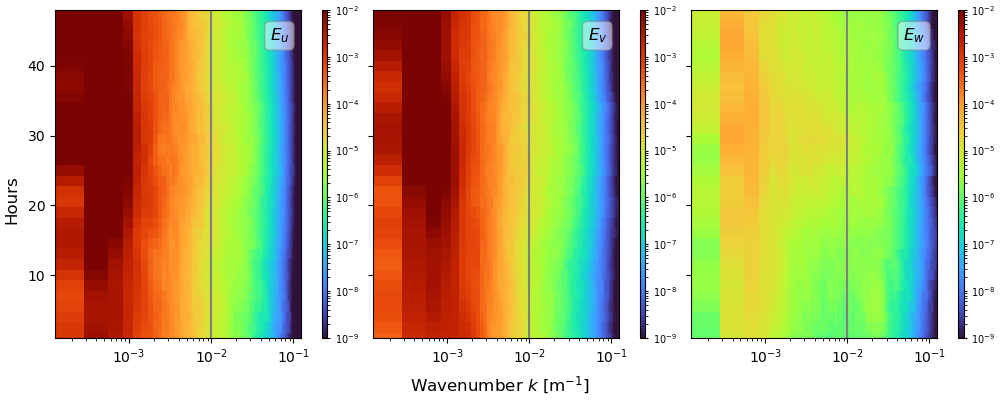

In [9]:
plt.close()
fig,ax = plt.subplots(1,3, figsize=(10,4), constrained_layout=True, sharex=True, sharey=True)

spec = spec0.copy()
lcut = 100

pcm0 = ax[0].pcolormesh(spec.wavenumber, spec.hour, spec.u, cmap='turbo', norm=mcl.LogNorm(vmin=1e-9, vmax=1e-2))
pcm1 = ax[1].pcolormesh(spec.wavenumber, spec.hour, spec.v, cmap='turbo', norm=mcl.LogNorm(vmin=1e-9, vmax=1e-2))
pcm2 = ax[2].pcolormesh(spec.wavenumber, spec.hour, spec.w, cmap='turbo', norm=mcl.LogNorm(vmin=1e-9, vmax=1e-2))

pcms = [pcm0, pcm1, pcm2]
panel_strs = [r'$E_u$', r'$E_v$', r'$E_w$']
for j in range(3):
    ax[j].axvline(1/lcut, color='gray')
    ax[j].text(0.95, 0.95, panel_strs[j], ha='right', va='top', transform=ax[j].transAxes, fontsize=12, fontweight='bold',
               bbox=dict(facecolor='w', edgecolor='gray', alpha=0.5, boxstyle='round,pad=0.3'))
    config_colorbar(pcms[j], ax[j], sci_notation=False)
    # ax[j].axvline(1/(5*4), color='k')
plt.xscale('log')
plt.xlim(1/8e3, 1/8)
plt.ylim(1, 48)
fig.supylabel('Hours')
fig.supxlabel(r'Wavenumber $k$ [m$^{-1}$]');

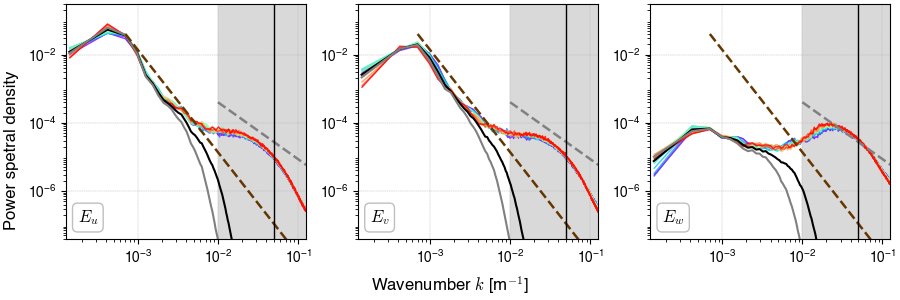

In [97]:
plt.close()
fig,ax = plt.subplots(1,3, figsize=(9,3), constrained_layout=True, sharex=True)

spec = spec3.copy()
lcut = 100
ksbm = np.array([1, 2e2]) * 7e-4
ksbw = np.array([1, 2e1]) * 1e-3
ktur = np.array([1, 2e1]) * 1e-2
ntime = spec.time.size

lines = [np.column_stack([spec.wavenumber, spec.u.isel(zC=-1)[i,:]]) for i in range(ntime)]
line_collection = LineCollection(lines, array=spec.hour[:ntime], cmap='rainbow', linewidths=1, alpha=0.8)
ax[0].add_collection(line_collection)
ax[0].set_ylim(4e-8, 3e-1)

lines = [np.column_stack([spec.wavenumber, spec.v.isel(zC=-1)[i,:]]) for i in range(ntime)]
line_collection = LineCollection(lines, array=spec.hour[:ntime], cmap='rainbow', linewidths=1, alpha=0.8)
ax[1].add_collection(line_collection)
ax[1].set_ylim(4e-8, 3e-1)

lines = [np.column_stack([spec.wavenumber, spec.w.isel(zC=-1)[i,:]]) for i in range(ntime)]
line_collection = LineCollection(lines, array=spec.hour[:ntime], cmap='rainbow', linewidths=1, alpha=0.8)
ax[2].add_collection(line_collection)
ax[2].set_ylim(4e-8, 3e-1)

mask = specl3.hour >= 6
ax[0].plot(specl3.wavenumber, specl3.u.isel(zC=-1).where(mask).mean('time'), c='k')
ax[1].plot(specl3.wavenumber, specl3.v.isel(zC=-1).where(mask).mean('time'), c='k')
ax[2].plot(specl3.wavenumber, specl3.w.isel(zC=-1).where(mask).mean('time'), c='k')

mask = spec_tmp3.hour >= 6
ax[0].plot(spec_tmp3.wavenumber, spec_tmp3.u.isel(zC=-1).where(mask).mean('time'), c='gray')
ax[1].plot(spec_tmp3.wavenumber, spec_tmp3.v.isel(zC=-1).where(mask).mean('time'), c='gray')
ax[2].plot(spec_tmp3.wavenumber, spec_tmp3.w.isel(zC=-1).where(mask).mean('time'), c='gray')

Esbm = np.array([1, 2e2**(-3)]) * 4e-2
Esbw = np.array([1, 2e1**(-0.5)]) * 2e-6
Etur = np.array([1, 2e1**(-5/3)]) * 4e-4
panel_strs = [r'$E_u$', r'$E_v$', r'$E_w$']
for j in range(3):
    if j < 3:
        ax[j].plot(ksbm, Esbm, '--', c='xkcd:brown', lw=1.8)
        # ax[j].plot(ksbw, Esbw, '--', c='xkcd:black', lw=1.8)
        ax[j].plot(ktur, Etur, '--', c='gray', lw=1.8)
    ax[j].grid(True, ls='--', lw=0.3)
    ax[j].set_yscale('log')
    ax[j].axvspan(1/lcut, 1/8, color='0.85')
    ax[j].axvline(1/(5*4), color='k', lw=1)
    ax[j].yaxis.set_major_locator(mticker.LogLocator(numticks=4))
    ax[j].text(0.05, 0.05, panel_strs[j], ha='left', va='bottom', transform=ax[j].transAxes, fontsize=12, fontweight='bold',
               bbox=dict(facecolor='w', edgecolor='gray', alpha=0.5, boxstyle='round,pad=0.3'))
plt.xscale('log')
plt.xlim(1/8e3, 1/8)
fig.supylabel('Power spetral density')
fig.supxlabel(r'Wavenumber $k$ [m$^{-1}$]');

### Tracer spectra

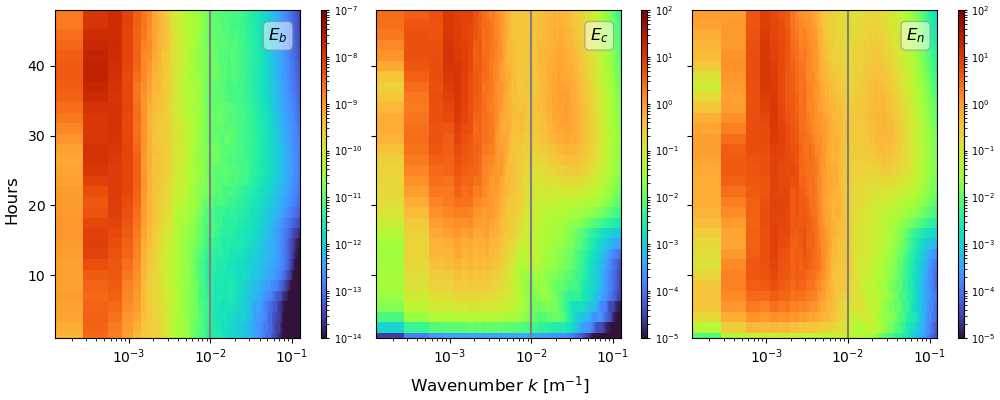

In [14]:
plt.close()
fig,ax = plt.subplots(1,3, figsize=(10,4), constrained_layout=True, sharex=True, sharey=True)

spec = spec1.copy()
lcut = 100

pcm0 = ax[0].pcolormesh(spec.wavenumber, spec.hour, spec.b, cmap='turbo', norm=mcl.LogNorm(vmin=1e-14, vmax=1e-7))
pcm1 = ax[1].pcolormesh(spec.wavenumber, spec.hour, spec.c, cmap='turbo', norm=mcl.LogNorm(vmin=1e-5, vmax=1e2))
pcm2 = ax[2].pcolormesh(spec.wavenumber, spec.hour, spec.n, cmap='turbo', norm=mcl.LogNorm(vmin=1e-5, vmax=1e2))

pcms = [pcm0, pcm1, pcm2]
panel_strs = [r'$E_b$', r'$E_c$', r'$E_n$']
for j in range(3):
    ax[j].axvline(1/lcut, color='gray')
    ax[j].text(0.95, 0.95, panel_strs[j], ha='right', va='top', transform=ax[j].transAxes, fontsize=12, fontweight='bold',
               bbox=dict(facecolor='w', edgecolor='gray', alpha=0.5, boxstyle='round,pad=0.3'))
    config_colorbar(pcms[j], ax[j], sci_notation=False)
    # ax[j].axvline(1/(5*4), color='k')
plt.xscale('log')
plt.xlim(1/8e3, 1/8)
plt.ylim(1, 48)
fig.supylabel('Hours')
fig.supxlabel(r'Wavenumber $k$ [m$^{-1}$]');

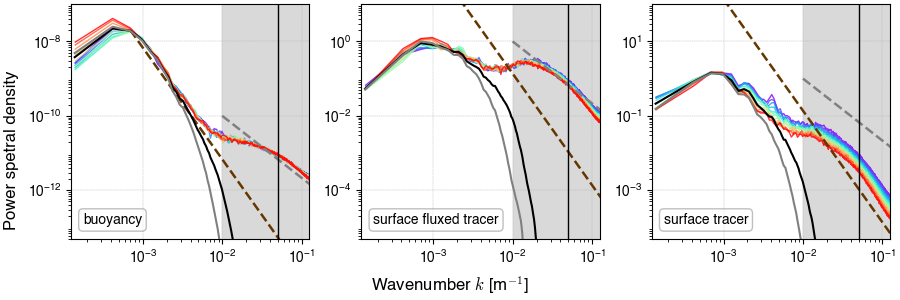

In [12]:
plt.close()
fig,ax = plt.subplots(1,3, figsize=(9,3), constrained_layout=True, sharex=True)

spec = spec3.copy()
lcut = 100
ksbm = np.array([1, 2e2]) * 7e-4
ktur = np.array([1, 2e1]) * 1e-2
ntime = spec.time.size

lines = [np.column_stack([spec.wavenumber, spec.b.isel(zC=-1)[i,:]]) for i in range(ntime)]
line_collection = LineCollection(lines, array=spec.hour[:ntime], cmap='rainbow', linewidths=1, alpha=0.8)
ax[0].add_collection(line_collection)
ax[0].set_ylim(5e-14, 1e-7)

Esbm = np.array([1, 2e2**(-3)]) * 2e-8
Etur = np.array([1, 2e1**(-5/3)]) * 1e-10
ax[0].plot(ksbm, Esbm, '--', c='xkcd:brown', lw=1.8)
ax[0].plot(ktur, Etur, '--', c='gray', lw=1.8)

lines = [np.column_stack([spec.wavenumber, spec.c.isel(zC=-1)[i,:]]) for i in range(ntime)]
line_collection = LineCollection(lines, array=spec.hour[:ntime], cmap='rainbow', linewidths=1, alpha=0.8)
ax[1].add_collection(line_collection)
ax[1].set_ylim(5e-6, 1e1)

lines = [np.column_stack([spec.wavenumber, spec.n.isel(zC=-1)[i,:]]) for i in range(ntime)]
line_collection = LineCollection(lines, array=spec.hour[:ntime], cmap='rainbow', linewidths=1, alpha=0.8)
ax[2].add_collection(line_collection)
ax[2].set_ylim(5e-5, 1e2)

mask = specl3.hour >= 6
ax[0].plot(specl3.wavenumber, specl3.b.isel(zC=-1).where(mask).mean('time'), c='k')
ax[1].plot(specl3.wavenumber, specl3.c.isel(zC=-1).where(mask).mean('time'), c='k')
ax[2].plot(specl3.wavenumber, specl3.n.isel(zC=-1).where(mask).mean('time'), c='k')

mask = spec_tmp3.hour >= 6
ax[0].plot(spec_tmp3.wavenumber, spec_tmp3.b.isel(zC=-1).where(mask).mean('time'), c='gray')
ax[1].plot(spec_tmp3.wavenumber, spec_tmp3.c.isel(zC=-1).where(mask).mean('time'), c='gray')
ax[2].plot(spec_tmp3.wavenumber, spec_tmp3.n.isel(zC=-1).where(mask).mean('time'), c='gray')


Esbm = np.array([1, 2e2**(-3)]) * 4e2
Etur = np.array([1, 2e1**(-5/3)]) * 1e0
panel_strs = [r'buoyancy', r'surface fluxed tracer', 'surface tracer']
for j in range(3):
    if j > 0:
        ax[j].plot(ksbm, Esbm, '--', c='xkcd:brown', lw=1.8)
        ax[j].plot(ktur, Etur, '--', c='gray', lw=1.8)
    ax[j].grid(True, ls='--', lw=0.3)
    ax[j].set_yscale('log')
    ax[j].axvspan(1/lcut, 1/8, color='0.85')
    ax[j].axvline(1/(5*4), color='k', lw=1)
    ax[j].yaxis.set_major_locator(mticker.LogLocator(numticks=5))
    ax[j].text(0.05, 0.05, panel_strs[j], ha='left', va='bottom', transform=ax[j].transAxes, fontsize=10,
               bbox=dict(facecolor='w', edgecolor='gray', alpha=0.5, boxstyle='round,pad=0.3'))
plt.xscale('log')
plt.xlim(1/8e3, 1/8)
fig.supylabel('Power spetral density')
fig.supxlabel(r'Wavenumber $k$ [m$^{-1}$]');

### Time-averaged spectra

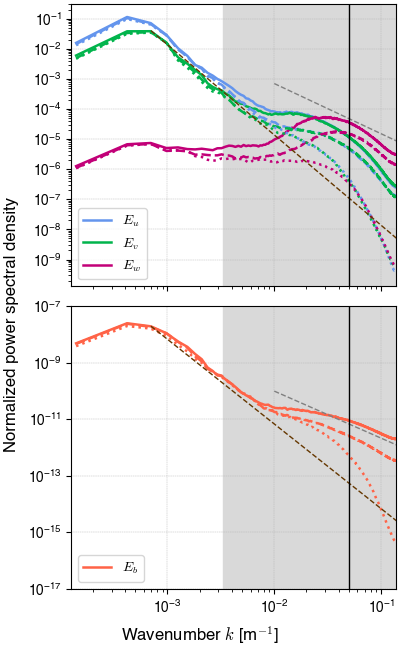

In [40]:
plt.close()
fig,ax = plt.subplots(2,1, figsize=(4,6.5), constrained_layout=True, sharex=True)

spec = [spec0, spec1, spec3]

lcut = 300
ksbm = np.array([1, 2e2]) * 7e-4
ktur = np.array([1, 2e1]) * 1e-2

ls_list = [':', '--', '-']
for i in reversed(range(3)):
    mask = (spec[i].hour >= 26) & (spec[i].hour <= 38)
    ax[0].loglog(spec[i].wavenumber, spec[i].u.where(mask).mean('time'), '#6495ed', ls=ls_list[i], lw=1.8)
    ax[0].loglog(spec[i].wavenumber, spec[i].v.where(mask).mean('time'), 'xkcd:shamrock', ls=ls_list[i], lw=1.8)
    ax[0].loglog(spec[i].wavenumber, spec[i].w.where(mask).mean('time'), 'xkcd:magenta', ls=ls_list[i], lw=1.8)
    ax[1].loglog(spec[i].wavenumber, spec[i].b.where(mask).mean('time'), '#ff6347', ls=ls_list[i], lw=1.8)

# mask = specl1.hour >= 42
# ax[0].loglog(specl1.wavenumber, specl1.u.where(mask).mean('time'), 'k', ls='--', lw=1.8)
# ax[0].loglog(specl1.wavenumber, specl1.v.where(mask).mean('time'), 'k', ls='--', lw=1.8)
# ax[0].loglog(specl1.wavenumber, specl1.w.where(mask).mean('time'), 'k', ls='--', lw=1.8)
# ax[1].loglog(specl1.wavenumber, specl1.b.where(mask).mean('time'), 'k', ls='--', lw=1.8)

ax[0].legend([r'$E_u$', r'$E_v$', r'$E_w$'], loc='lower left')
ax[1].legend([r'$E_b$'], loc='lower left')

Esbm = np.array([1, 2e2**(-3)]) * 4e-2
Etur = np.array([1, 2e1**(-5/3)]) * 7e-4
ax[0].loglog(ksbm, Esbm, '--', c='xkcd:brown', lw=1)
ax[0].loglog(ktur, Etur, '--', c='gray', lw=1)
ax[0].axvspan(1/lcut, 1/3.64/2, color='0.85')
ax[0].axvline(1/(5*4), color='k', lw=1)

Esbm = np.array([1, 2e2**(-3)]) * 2e-8
Etur = np.array([1, 2e1**(-5/3)]) * 1e-10
ax[1].loglog(ksbm, Esbm, '--', c='xkcd:brown', lw=1)
ax[1].loglog(ktur, Etur, '--', c='gray', lw=1)
ax[1].axvspan(1/lcut, 1/3.64/2, color='0.85')
ax[1].axvline(1/(5*4), color='k', lw=1)
ax[1].set_ylim(1e-17, 1e-7)

ax[0].grid(True, ls='--', lw=0.3)
ax[1].grid(True, ls='--', lw=0.3)
plt.xlim(1/8e3, 1/3.64/2)
fig.supxlabel(r'Wavenumber $k$ [m$^{-1}$]')
fig.supylabel('Normalized power spectral density');

### Figure for the paper: velocity and tracer spectra from one snapshot

In [13]:
it0 = -1

# hspec0m = hspec0.isel(zC=-1,time=slice(it0,None)).mean('time')
spec0m = spec0.isel(zC=-1,time=slice(it0,None)).mean('time')
spec1m = spec1.isel(zC=-1,time=slice(it0,None)).mean('time')
spec3m = spec3.isel(zC=-1,time=slice(it0,None)).mean('time')

specl0m = specl0.isel(zC=-1,time=slice(it0,None)).mean('time')
specl1m = specl1.isel(zC=-1,time=slice(it0,None)).mean('time')
specl3m = specl3.isel(zC=-1,time=slice(it0,None)).mean('time')

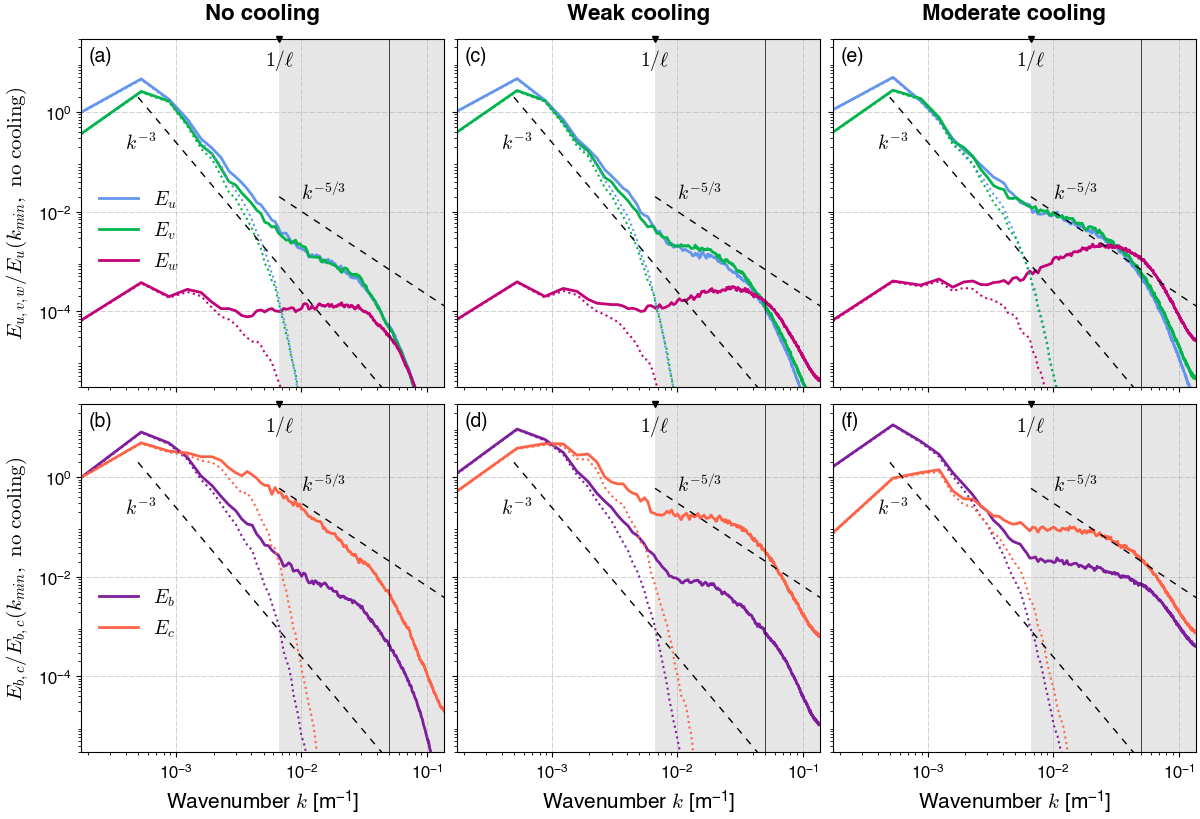

In [15]:
plt.close()
fig,ax = plt.subplots(2,3, figsize=(12,8.2), constrained_layout=True, sharex=True, sharey='row')

spec  = [spec0m, spec1m, spec3m]
specl = [specl0m, specl1m, specl3m]

lcut = 150
ksbm = np.array([1, 4e2]) * 5e-4
ktur = np.array([1, 4e1]) * 1/lcut
Esbm = np.array([1, 4e2**(-3)]) * 2e0
Etur = np.array([1, 4e1**(-5/3)]) * 2e-2
Etur_scale = [1, 3e1]
title_str = ['No cooling', 'Weak cooling', 'Moderate cooling']
subp_str  = 'abcdef'
count = 0

spec_kmin_u = spec[0].u[0].data
spec_kmin_b = spec[0].b[0].data
spec_kmin_c = spec[0].c[0].data

# spec_kmin_u = hspec0m.u[0].data
# spec_kmin_b = hspec0m.b[0].data
# spec_kmin_c = hspec0m.c[0].data

for j in range(3):
    ax[0,j].loglog(spec[j].wavenumber, spec[j].u/spec_kmin_u, '#6495ed', lw=2)
    ax[0,j].loglog(spec[j].wavenumber, spec[j].v/spec_kmin_u, 'xkcd:shamrock', lw=2)
    ax[0,j].loglog(spec[j].wavenumber, spec[j].w/spec_kmin_u, 'xkcd:magenta', lw=2)
    ax[1,j].loglog(spec[j].wavenumber, spec[j].b/spec_kmin_b, 'xkcd:purple', lw=2)
    ax[1,j].loglog(spec[j].wavenumber, spec[j].c/spec_kmin_c, '#ff6347', lw=2)

    ax[0,j].loglog(specl[j].wavenumber, specl[j].u/spec_kmin_u, '#6495ed', lw=1.5, ls=':')
    ax[0,j].loglog(specl[j].wavenumber, specl[j].v/spec_kmin_u, 'xkcd:shamrock', lw=1.5, ls=':')
    ax[0,j].loglog(specl[j].wavenumber, specl[j].w/spec_kmin_u, 'xkcd:magenta', lw=1.5, ls=':')
    ax[1,j].loglog(specl[j].wavenumber, specl[j].b/spec_kmin_b, 'xkcd:purple', lw=1.5, ls=':')
    ax[1,j].loglog(specl[j].wavenumber, specl[j].c/spec_kmin_c, '#ff6347', lw=1.5, ls=':')

    for i in range(2):
        ax[i,j].plot(1/lcut, 3e1, 'vk', ms=5, clip_on=False)
        ax[i,j].text(1/lcut, 2e1, r'$1/\ell$', fontsize=14, ha='center', va='top')
        ax[i,j].text(0.02, 0.98, f'({subp_str[count]})', fontsize=14, ha='left', va='top', transform=ax[i,j].transAxes)
        ax[i,j].loglog(ksbm, Esbm,               ls=(0, (5, 5)), c='k', lw=1)
        ax[i,j].loglog(ktur, Etur*Etur_scale[i], ls=(0, (5, 5)), c='k', lw=1)
        ax[i,j].axvspan(1/lcut, 1/3.64/2, color='0.9', ec='none')
        ax[i,j].axvline(1/(5*4), color='k', lw=0.5)
        ax[i,j].grid(True, ls=(5, (10, 3)), lw=0.4)
        ax[i,j].text(7e-4, 4e-1, r'$k^{-3}$', fontsize=14, ha='right', va='top')
        if i == 1:
            ax[i,j].set_xlabel(r'Wavenumber $k$ [m$\mathregular{^{-1}}$]', fontsize=15)
            ax[i,j].text(1e-2, 4.5e-1, r'$k^{-5/3}$', fontsize=14, ha='left',  va='bottom')
        else:
            ax[i,j].set_title(f'{title_str[j]}', fontsize=16, fontweight='bold', pad=14)
            ax[i,j].text(1e-2, 1.5e-2, r'$k^{-5/3}$', fontsize=14, ha='left',  va='bottom')
        count += 1

plt.xlim(1/4e3/np.sqrt(2), 1/3.64/2)
ax[0,0].set_ylim(3e-6, 3e1)
ax[1,0].set_ylim(3e-6, 3e1)
ax[0,0].set_yticks([1e-4, 1e-2, 1e0])
ax[1,0].set_yticks([1e-4, 1e-2, 1e0])

ax[0,0].legend([r'$E_u$', r'$E_v$', r'$E_w$'], loc='center left', frameon=False, fontsize=14, bbox_to_anchor=(0, 0.45))
ax[1,0].legend([r'$E_b$', r'$E_c$'], loc='center left', frameon=False, fontsize=14, bbox_to_anchor=(0, 0.4))
ax[0,0].set_ylabel(r'$E_{u,v,w} / E_u(k_{min}, \ \mathrm{no \ cooling})$',   fontsize=15)
ax[1,0].set_ylabel(r'$E_{b,c} / E_{b,c}(k_{min}, \ \mathrm{no \ cooling})$', fontsize=15);

plt.savefig(f'../Figures/spectra.png', dpi=300);
# plt.savefig(f'../Figures/spectra_low-res.png', dpi=300);